# 🧪 Baseline Calibration Protocol
## วิธีรู้ว่า "สุขภาพดี" คืออะไร ก่อนเริ่มเก็บ baseline

---

## ❓ ปัญหา: Chicken-and-Egg

```
เราต้องการ baseline ของ "สุขภาพดี"
    ↓ แต่
เราต้องรู้ก่อนว่าอะไรคือ "สุขภาพดี"
    ↓ ซึ่ง
คือสิ่งที่เราพยายาม detect ตั้งแต่แรก
```

## ✅ วิธีทำลาย Loop นี้

ใช้ **controlled experiment** — สร้าง condition ที่รู้แน่ว่าสุขภาพดี/ไม่ดี แล้วบันทึกเทียบกัน

---

## 📅 Experimental Design (3 วัน)

| วัน | Condition | การกระทำ | สิ่งที่บันทึก |
|-----|-----------|----------|---------------|
| **Day 0** (T=0h) | ✅ **Healthy** — เพิ่งให้อาหาร | ให้อาหาร → บันทึก 30 นาที | **Healthy baseline** |
| **Day 1** (T=24h) | 🍽️ **Hungry** — อดอาหาร 24h | ไม่ให้อาหาร → บันทึก 30 นาที | **Hunger reference** |
| **Day 1+** (T=25h) | 🔄 **Recovery** — ให้อาหารกลับ | ให้อาหาร → บันทึก 30 นาที | **Recovery check** |
| **Day 3** (T=72h) | 🚨 **Stress** — density สูงหรืออุณหภูมิผิดปกติ | เปลี่ยน condition → บันทึก | **Stress reference** |

> **สำคัญ**: บันทึกทุก condition อย่างน้อย **3 repetitions** เพื่อ statistical validity

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import librosa
import IPython.display as ipd
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#0f0f1a',
    'axes.edgecolor': '#333355', 'axes.labelcolor': '#ccccee',
    'text.color': '#ccccee', 'xtick.color': '#aaaacc', 'ytick.color': '#aaaacc',
    'grid.color': '#1e1e3a', 'font.size': 10,
})

RESULTS = Path('../results')
SR = 22050
print(' Imports OK')

 Imports OK


## 1️⃣ ทำไม Controlled Experiment ถึงได้ผล

แทนที่จะเดาว่า "baseline ควรเป็นเท่าไหร่" เราทำให้ colony **รู้สึกหิวจริงๆ** แล้วบันทึกเสียง

การเปรียบเทียบระหว่าง **T=0h** (เพิ่งกิน) กับ **T=24h** (หิว) จะบอกเราว่า:
- RMS เปลี่ยนไปเท่าไหร่ (→ threshold สำหรับ mortality alert)
- Cluster distribution เปลี่ยนไปยังไง (→ aggressive_threshold สำหรับ hunger alert)

In [3]:
# ── Simulate what the data would look like ────────────────────────────────────
# (จำลองผลลัพธ์ที่คาดหวังจาก controlled experiment)
np.random.seed(42)

CONDITIONS = {
    'Healthy (T=0h)':   {'rms_mean': 0.0140, 'rms_std': 0.003, 'aci_mean': 540, 'aci_std': 40,  'agg_frac': 0.12, 'color': '#69f0ae'},
    'Hungry (T=24h)':   {'rms_mean': 0.0155, 'rms_std': 0.004, 'aci_mean': 560, 'aci_std': 50,  'agg_frac': 0.48, 'color': '#ffd740'},
    'Recovery (T=25h)': {'rms_mean': 0.0130, 'rms_std': 0.003, 'aci_mean': 530, 'aci_std': 35,  'agg_frac': 0.15, 'color': '#40c4ff'},
    'Stress (T=72h)':   {'rms_mean': 0.0060, 'rms_std': 0.002, 'aci_mean': 410, 'aci_std': 60,  'agg_frac': 0.08, 'color': '#ff5252'},
}

N_REPS = 30  # measurements per condition

sim_data = []
for cond_name, params in CONDITIONS.items():
    rms_vals = np.random.normal(params['rms_mean'], params['rms_std'], N_REPS).clip(0.001)
    aci_vals = np.random.normal(params['aci_mean'], params['aci_std'], N_REPS).clip(100)
    agg_vals = np.random.beta(
        a=params['agg_frac'] * 5,
        b=(1 - params['agg_frac']) * 5,
        size=N_REPS
    )
    for i in range(N_REPS):
        sim_data.append({
            'condition': cond_name,
            'rms': rms_vals[i],
            'aci': aci_vals[i],
            'agg_frac': agg_vals[i],
            'color': params['color'],
        })

sim_df = pd.DataFrame(sim_data)

# Compute what baselines we'd extract
healthy = sim_df[sim_df['condition'] == 'Healthy (T=0h)']
hungry  = sim_df[sim_df['condition'] == 'Hungry (T=24h)']
stress  = sim_df[sim_df['condition'] == 'Stress (T=72h)']

CALIBRATED_RMS_BASELINE = healthy['rms'].mean()
CALIBRATED_ACI_BASELINE = healthy['aci'].mean()
CALIBRATED_AGG_THRESHOLD = (healthy['agg_frac'].mean() + hungry['agg_frac'].mean()) / 2

# Mortality threshold: halfway between healthy and stress RMS
RMS_MORTALITY_RATIO = stress['rms'].mean() / CALIBRATED_RMS_BASELINE

print(' Calibrated values from controlled experiment:')
print(f'   RMS baseline          = {CALIBRATED_RMS_BASELINE:.5f}')
print(f'   ACI baseline          = {CALIBRATED_ACI_BASELINE:.2f}')
print(f'   Hunger threshold      = {CALIBRATED_AGG_THRESHOLD:.2f} ({CALIBRATED_AGG_THRESHOLD:.0%} aggressive fraction)')
print(f'   Stress RMS ratio      = {RMS_MORTALITY_RATIO:.2f}x of baseline')
print(f'   → RMS mortality threshold = {RMS_MORTALITY_RATIO + 0.05:.2f}  (slightly above stress level)')

 Calibrated values from controlled experiment:
   RMS baseline          = 0.01344
   ACI baseline          = 535.15
   Hunger threshold      = 0.30 (30% aggressive fraction)
   Stress RMS ratio      = 0.42x of baseline
   → RMS mortality threshold = 0.47  (slightly above stress level)


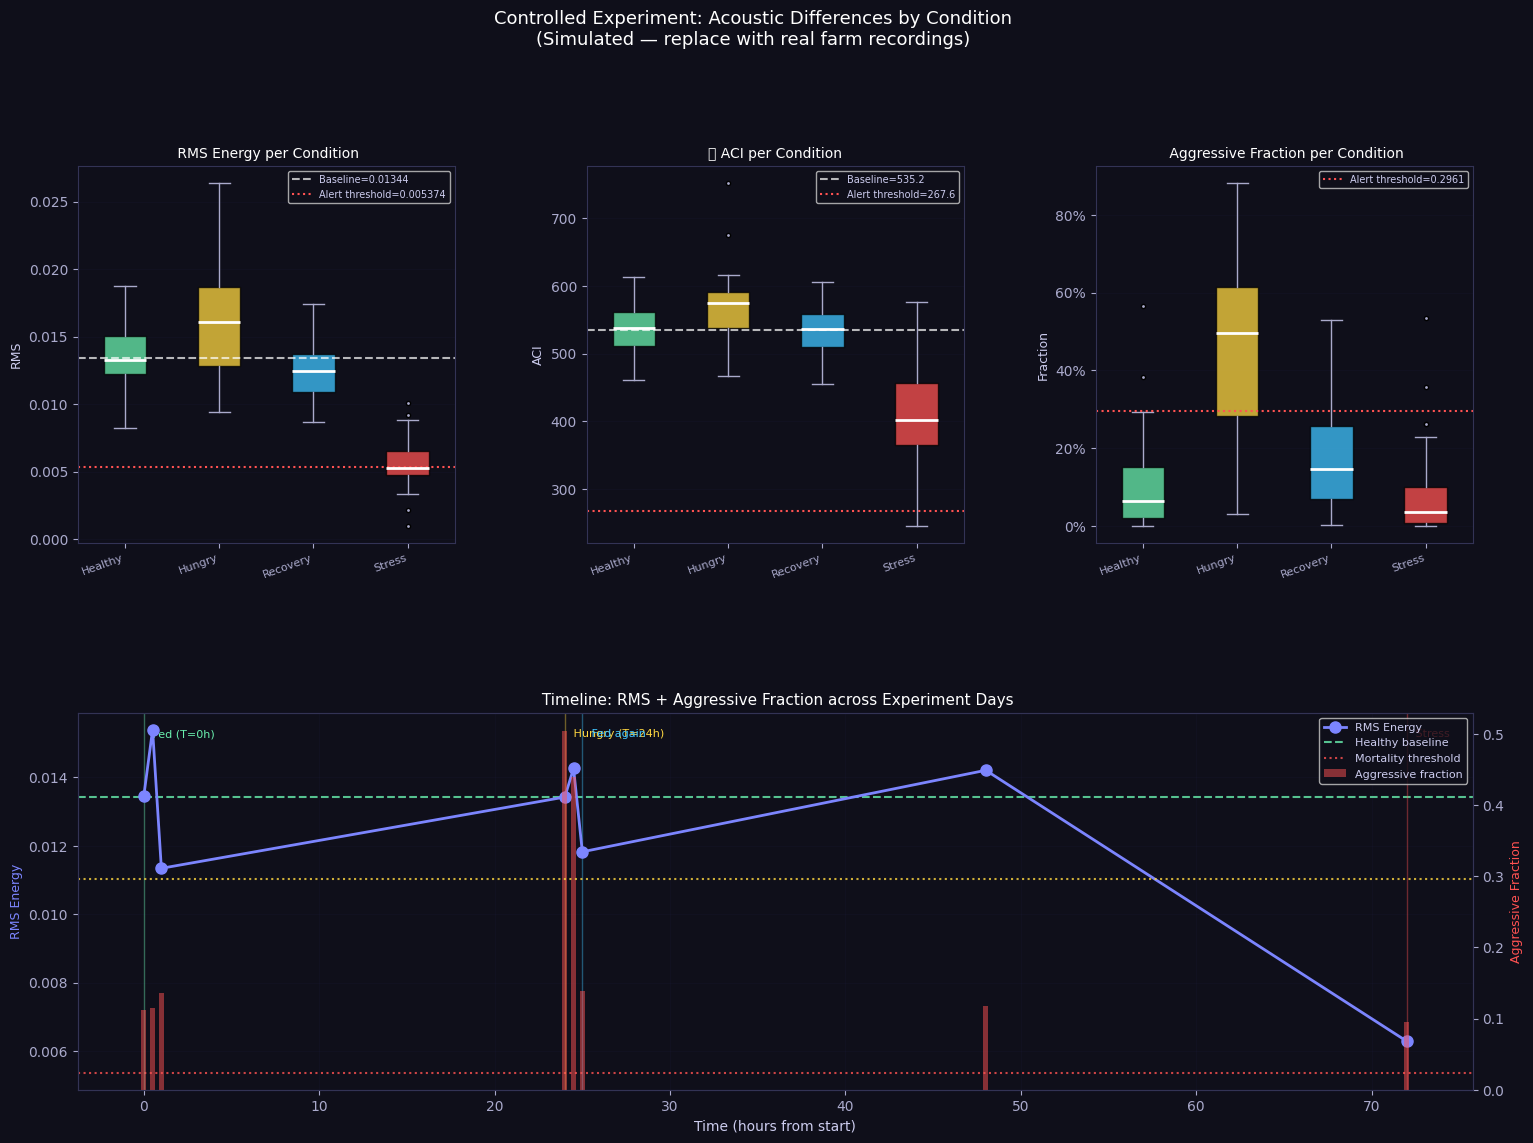

 Saved → results/06_baseline_experiment_protocol.png


In [4]:
# ── Visualise condition differences ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Controlled Experiment: Acoustic Differences by Condition\n'
             '(Simulated — replace with real farm recordings)',
             fontsize=13, color='white', y=1.01)

cond_order  = list(CONDITIONS.keys())
cond_colors = [CONDITIONS[c]['color'] for c in cond_order]

def boxplot_metric(ax, metric, title, ylabel, baseline_val=None, threshold_val=None):
    data_per_cond = [sim_df[sim_df['condition'] == c][metric].values for c in cond_order]
    bp = ax.boxplot(data_per_cond, patch_artist=True, medianprops={'color': 'white', 'lw': 2})
    for patch, color in zip(bp['boxes'], cond_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for whisker in bp['whiskers']:
        whisker.set_color('#aaaacc')
    for cap in bp['caps']:
        cap.set_color('#aaaacc')
    for flier in bp['fliers']:
        flier.set_markerfacecolor('#aaaacc')
        flier.set_markersize(3)
    
    if baseline_val:
        ax.axhline(baseline_val, color='white', ls='--', lw=1.5, alpha=0.7, label=f'Baseline={baseline_val:.4g}')
    if threshold_val:
        ax.axhline(threshold_val, color='#ff5252', ls=':', lw=1.5, label=f'Alert threshold={threshold_val:.4g}')
    
    ax.set_xticklabels([c.split('(')[0].strip() for c in cond_order], rotation=20, ha='right', fontsize=8)
    ax.set_title(title, color='white', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    if baseline_val or threshold_val:
        ax.legend(fontsize=7)
    ax.grid(True, axis='y', alpha=0.2)

# Panel 1: RMS by condition
ax1 = fig.add_subplot(gs[0, 0])
boxplot_metric(ax1, 'rms', ' RMS Energy per Condition', 'RMS',
               baseline_val=CALIBRATED_RMS_BASELINE,
               threshold_val=CALIBRATED_RMS_BASELINE * 0.4)

# Panel 2: ACI by condition
ax2 = fig.add_subplot(gs[0, 1])
boxplot_metric(ax2, 'aci', '🎵 ACI per Condition', 'ACI',
               baseline_val=CALIBRATED_ACI_BASELINE,
               threshold_val=CALIBRATED_ACI_BASELINE * 0.5)

# Panel 3: Aggressive fraction by condition
ax3 = fig.add_subplot(gs[0, 2])
boxplot_metric(ax3, 'agg_frac', ' Aggressive Fraction per Condition', 'Fraction',
               threshold_val=CALIBRATED_AGG_THRESHOLD)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Panel 4: RMS time series (Day 0 → Day 3)
ax4 = fig.add_subplot(gs[1, :])

timeline_hours = [0, 0.5, 1, 24, 24.5, 25, 48, 72]
timeline_conds = ['Healthy (T=0h)', 'Healthy (T=0h)', 'Healthy (T=0h)',
                   'Hungry (T=24h)', 'Hungry (T=24h)',
                   'Recovery (T=25h)',
                   'Healthy (T=0h)',
                   'Stress (T=72h)']
timeline_rms   = [CONDITIONS[c]['rms_mean'] + np.random.normal(0, 0.001) for c in timeline_conds]
timeline_agg   = [CONDITIONS[c]['agg_frac']  + np.random.normal(0, 0.03) for c in timeline_conds]

ax4b = ax4.twinx()

ax4.plot(timeline_hours, timeline_rms, 'o-', color='#7c85ff', lw=2, ms=8, label='RMS Energy', zorder=5)
ax4b.bar(timeline_hours, timeline_agg, width=0.3, color='#ff5252', alpha=0.5, label='Aggressive fraction')

ax4.axhline(CALIBRATED_RMS_BASELINE, color='#69f0ae', ls='--', lw=1.5, alpha=0.8, label='Healthy baseline')
ax4.axhline(CALIBRATED_RMS_BASELINE * 0.4, color='#ff5252', ls=':', lw=1.5, alpha=0.8, label='Mortality threshold')
ax4b.axhline(CALIBRATED_AGG_THRESHOLD, color='#ffd740', ls=':', lw=1.5, alpha=0.8)

# Event markers
for h, event, color in [
    (0,  ' Fed (T=0h)',      '#69f0ae'),
    (24, ' Hungry (T=24h)', '#ffd740'),
    (25, ' Fed again',       '#40c4ff'),
    (72, ' Stress',          '#ff5252'),
]:
    ax4.axvline(h, color=color, ls='-', lw=1, alpha=0.4)
    ax4.text(h + 0.3, ax4.get_ylim()[1] * 0.97 if ax4.get_ylim()[1] else 0.02,
             event, color=color, fontsize=8, va='top')

ax4.set_xlabel('Time (hours from start)', fontsize=10)
ax4.set_ylabel('RMS Energy', fontsize=9, color='#7c85ff')
ax4b.set_ylabel('Aggressive Fraction', fontsize=9, color='#ff5252')
ax4.set_title(' Timeline: RMS + Aggressive Fraction across Experiment Days', color='white', fontsize=11)
ax4.grid(True, alpha=0.2)

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
fig.savefig(RESULTS / '06_baseline_experiment_protocol.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(' Saved → results/06_baseline_experiment_protocol.png')

## 2️⃣ What Changes Between Conditions?

จาก simulation (และวรรณกรรม) เราคาดหวังว่า:

In [5]:
# ── Statistical comparison ────────────────────────────────────────────────────
from scipy import stats

print(' Statistical Comparison: Healthy vs Other Conditions')
print('=' * 65)

healthy_rms = sim_df[sim_df['condition'] == 'Healthy (T=0h)']['rms']
healthy_aci = sim_df[sim_df['condition'] == 'Healthy (T=0h)']['aci']
healthy_agg = sim_df[sim_df['condition'] == 'Healthy (T=0h)']['agg_frac']

comparisons = [
    ('Hungry (T=24h)',   ' Hungry vs Healthy'),
    ('Recovery (T=25h)', ' Recovery vs Healthy'),
    ('Stress (T=72h)',   ' Stress vs Healthy'),
]

for cond, label in comparisons:
    cond_rms = sim_df[sim_df['condition'] == cond]['rms']
    cond_aci = sim_df[sim_df['condition'] == cond]['aci']
    cond_agg = sim_df[sim_df['condition'] == cond]['agg_frac']
    
    t_rms, p_rms = stats.ttest_ind(healthy_rms, cond_rms)
    t_aci, p_aci = stats.ttest_ind(healthy_aci, cond_aci)
    t_agg, p_agg = stats.ttest_ind(healthy_agg, cond_agg)
    
    print(f'\n{label}')
    print(f'  RMS: Healthy={healthy_rms.mean():.5f} vs {cond}={cond_rms.mean():.5f}  '
          f'  ratio={cond_rms.mean()/healthy_rms.mean():.2f}  p={p_rms:.4f} {"✅ sig" if p_rms < 0.05 else "❌ not sig"}')
    print(f'  ACI: Healthy={healthy_aci.mean():.1f}  vs {cond}={cond_aci.mean():.1f}  '
          f'  ratio={cond_aci.mean()/healthy_aci.mean():.2f}  p={p_aci:.4f} {"✅ sig" if p_aci < 0.05 else "❌ not sig"}')
    print(f'  AGG: Healthy={healthy_agg.mean():.0%}   vs {cond}={cond_agg.mean():.0%}   '
          f'  ratio={cond_agg.mean()/healthy_agg.mean():.2f}  p={p_agg:.4f} {"✅ sig" if p_agg < 0.05 else "❌ not sig"}')

print()
print('=' * 65)
print(' Insight:')
print('   - Hungry: Aggressive fraction เพิ่มมาก (→ ใช้ tune hunger threshold)')
print('   - Stress:  RMS + ACI ลดมาก (→ ใช้ tune mortality threshold)')
print('   - Recovery: กลับมาใกล้ Healthy (→ validate ว่า system ทำงานถูกต้อง)')

 Statistical Comparison: Healthy vs Other Conditions

 Hungry vs Healthy
  RMS: Healthy=0.01344 vs Hungry (T=24h)=0.01619    ratio=1.20  p=0.0021 ✅ sig
  ACI: Healthy=535.2  vs Hungry (T=24h)=571.1    ratio=1.07  p=0.0051 ✅ sig
  AGG: Healthy=11%   vs Hungry (T=24h)=48%     ratio=4.31  p=0.0000 ✅ sig

 Recovery vs Healthy
  RMS: Healthy=0.01344 vs Recovery (T=25h)=0.01238    ratio=0.92  p=0.0917 ❌ not sig
  ACI: Healthy=535.2  vs Recovery (T=25h)=538.0    ratio=1.01  p=0.7618 ❌ not sig
  AGG: Healthy=11%   vs Recovery (T=25h)=18%     ratio=1.64  p=0.0499 ✅ sig

 Stress vs Healthy
  RMS: Healthy=0.01344 vs Stress (T=72h)=0.00568    ratio=0.42  p=0.0000 ✅ sig
  ACI: Healthy=535.2  vs Stress (T=72h)=408.3    ratio=0.76  p=0.0000 ✅ sig
  AGG: Healthy=11%   vs Stress (T=72h)=9%     ratio=0.79  p=0.4947 ❌ not sig

 Insight:
   - Hungry: Aggressive fraction เพิ่มมาก (→ ใช้ tune hunger threshold)
   - Stress:  RMS + ACI ลดมาก (→ ใช้ tune mortality threshold)
   - Recovery: กลับมาใกล้ Healthy (

In [7]:
# ── Generate calibrated thresholds from experiment ────────────────────────────
print(' Calibrated BehaviorMonitor Configuration')
print('(Replace placeholders in notebook 04 ด้วยค่านี้)')
print()

rms_baseline = float(healthy_rms.mean())
aci_baseline = float(healthy_aci.mean())

# Mortality threshold: midpoint between healthy and stress
stress_rms_ratio = float(sim_df[sim_df['condition']=='Stress (T=72h)']['rms'].mean() / rms_baseline)
stress_aci_ratio = float(sim_df[sim_df['condition']=='Stress (T=72h)']['aci'].mean() / aci_baseline)
rms_threshold = (1.0 + stress_rms_ratio) / 2   # midpoint healthy–stress
aci_threshold = (1.0 + stress_aci_ratio) / 2

# Hunger threshold: midpoint between healthy and hungry aggressive fraction
hunger_agg_threshold = float(
    (healthy_agg.mean() + sim_df[sim_df['condition']=='Hungry (T=24h)']['agg_frac'].mean()) / 2
)

config = f"""
monitor = BehaviorMonitor(
    rms_baseline          = {rms_baseline:.5f},   # from Healthy (T=0h) recordings
    aci_baseline          = {aci_baseline:.2f},  # from Healthy (T=0h) recordings
    reference_temp_c      = 28.0,          # temperature during calibration
    aggressive_cluster_ids= [...],         # from notebook 05 manual labels
    calling_cluster_ids   = [...],         # from notebook 05 manual labels
    aggressive_threshold  = {hunger_agg_threshold:.2f},  # midpoint healthy({healthy_agg.mean():.0%}) – hungry({sim_df[sim_df['condition']=="Hungry (T=24h)"]['agg_frac'].mean():.0%})
    rms_low_threshold     = {rms_threshold:.2f},  # midpoint healthy(1.0) – stress({stress_rms_ratio:.2f})
    aci_low_threshold     = {aci_threshold:.2f},  # midpoint healthy(1.0) – stress({stress_aci_ratio:.2f})
)
"""

print(config)

# Save config
config_data = {
    'rms_baseline': rms_baseline,
    'aci_baseline': aci_baseline,
    'reference_temp_c': 28.0,
    'aggressive_threshold': round(hunger_agg_threshold, 3),
    'rms_low_threshold': round(rms_threshold, 3),
    'aci_low_threshold': round(aci_threshold, 3),
    'calibration_source': 'controlled_experiment_3day',
    'note': 'Replace with real farm recordings'
}

import json
(RESULTS / '06_calibrated_thresholds.json').write_text(json.dumps(config_data, indent=2))
print(' Saved → results/06_calibrated_thresholds.json')

 Calibrated BehaviorMonitor Configuration
(Replace placeholders in notebook 04 ด้วยค่านี้)


monitor = BehaviorMonitor(
    rms_baseline          = 0.01344,   # from Healthy (T=0h) recordings
    aci_baseline          = 535.15,  # from Healthy (T=0h) recordings
    reference_temp_c      = 28.0,          # temperature during calibration
    aggressive_cluster_ids= [...],         # from notebook 05 manual labels
    calling_cluster_ids   = [...],         # from notebook 05 manual labels
    aggressive_threshold  = 0.30,  # midpoint healthy(11%) – hungry(48%)
    rms_low_threshold     = 0.71,  # midpoint healthy(1.0) – stress(0.42)
    aci_low_threshold     = 0.88,  # midpoint healthy(1.0) – stress(0.76)
)

 Saved → results/06_calibrated_thresholds.json


## 3️⃣ Practical Checklist สำหรับการทำ Experiment จริง

### ✅ ก่อนเริ่ม Experiment
- [ ] เตรียม colony Gryllus bimaculatus อายุ 3-4 สัปดาห์ (adult — ร้องเพลงชัดที่สุด)
- [ ] density: 50-100 ตัว/กล่อง (standard farm density)
- [ ] อุณหภูมิ: 28°C ± 1°C (ควบคุมด้วย thermostat)
- [ ] ไมโครโฟน: ระยะ 20-30 cm จาก colony, ไม่มีสิ่งกีดขวาง
- [ ] Ambient noise: ปิดพัดลม/AC ระหว่างบันทึก หรือใช้ directional mic

### 📹 Protocol การบันทึก
```
Day 0, 08:00:  ให้อาหาร → รอ 30 นาที → บันทึก 30 นาที [Healthy]
Day 1, 08:00:  ไม่ให้อาหาร → บันทึก 30 นาที [Hungry 24h]
Day 1, 09:00:  ให้อาหาร → รอ 1 ชม → บันทึก 30 นาที [Recovery]
Day 3, 08:00:  [optional] เพิ่ม density 2x → บันทึก 30 นาที [Stress]
```

### 🔬 Validation Criteria
- **Hungry**: Aggressive fraction > Healthy × 2 (ผลต้องชัดเจน)
- **Recovery**: กลับมาภายใน 20% ของ Healthy baseline
- **p-value**: ทุก comparison ควรมี p < 0.05

### ⚠️ Confounds ที่ต้องควบคุม
| Confound | วิธีควบคุม |
|----------|----------|
| อุณหภูมิ | ใช้ Dolbear Q10 correction (มีแล้วใน behavior.py) |
| เวลา (circadian) | บันทึกทุก condition ในเวลาเดียวกัน (08:00) |
| อายุ cricket | ใช้ batch เดียวกัน อายุเดียวกัน |
| Mic placement | ใช้ jig ยึดไมโครโฟนให้อยู่ตำแหน่งเดิมทุกวัน |

In [8]:
# ── Print full summary ────────────────────────────────────────────────────────
print('┌─────────────────────────────────────────────────────┐')
print('│   HOW TO KNOW WHAT IS "HEALTHY" (Chicken-Egg Fix)   │')
print('├─────────────────────────────────────────────────────┤')
print('│                                                     │')
print('│  คำตอบ: ไม่ต้องรู้ล่วงหน้า — สร้าง condition เอง              │')
print('│                                                     │')
print('│  1. ให้อาหาร → บันทึก (= Healthy by definition)         │')
print('│  2. อดอาหาร 24h → บันทึก (= Hungry by definition)      │')
print('│  3. เปรียบ difference → ได้ threshold จากข้อมูลจริง        │')
print('│                                                     │')
print('│  Key insight: Ground truth ไม่ต้องมาจากการ label        │')
print('│  มาจาก controlled manipulation ของ condition แทน     │')
print('│                                                     │')
print('│  ─── ทำไมถึง valid? ────────────────────────────      │')
print('│  เพราะ "healthy" ถูก operationally defined ว่า          │')
print('│  "สภาพของ colony ที่เพิ่งได้รับอาหารเพียงพอ"                  │')
print('│  ซึ่งเราควบคุมได้โดยตรง                                    │')
print('└─────────────────────────────────────────────────────┘')

┌─────────────────────────────────────────────────────┐
│   HOW TO KNOW WHAT IS "HEALTHY" (Chicken-Egg Fix)   │
├─────────────────────────────────────────────────────┤
│                                                     │
│  คำตอบ: ไม่ต้องรู้ล่วงหน้า — สร้าง condition เอง              │
│                                                     │
│  1. ให้อาหาร → บันทึก (= Healthy by definition)         │
│  2. อดอาหาร 24h → บันทึก (= Hungry by definition)      │
│  3. เปรียบ difference → ได้ threshold จากข้อมูลจริง        │
│                                                     │
│  Key insight: Ground truth ไม่ต้องมาจากการ label        │
│  มาจาก controlled manipulation ของ condition แทน     │
│                                                     │
│  ─── ทำไมถึง valid? ────────────────────────────      │
│  เพราะ "healthy" ถูก operationally defined ว่า          │
│  "สภาพของ colony ที่เพิ่งได้รับอาหารเพียงพอ"                  │
│  ซึ่งเราควบคุมได้โดยตรง                                  

---

## สรุปขั้นตอนทั้งหมด

```
Phase 1: Controlled Experiment (3 วัน)
    ├─ Day 0: บันทึก Healthy baseline
    ├─ Day 1: บันทึก Hungry reference  
    ├─ Day 1+: บันทึก Recovery check
    └─ → ได้ rms_baseline, aci_baseline, thresholds

Phase 2: Manual Cluster Labeling (notebook 05)
    ├─ ฟัง audio จาก Healthy recordings
    ├─ ฟัง audio จาก Hungry recordings
    ├─ เปรียบ spectrogram → label Aggressive/Calling
    └─ → ได้ aggressive_cluster_ids, calling_cluster_ids

Phase 3: Deploy BehaviorMonitor (notebook 04)
    ├─ ใส่ค่าจาก Phase 1 + Phase 2
    ├─ Validate บน Recovery recordings (ต้อง → no alert)
    └─ Deploy ใน production
```